# Evaluation

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Load ranking results (file expected at project root)
df = pd.read_csv('../ranking_results_with_hybrid.csv')
df.head()

,model,K,Precision@K,Recall@K,ARR,NDCG@K,MAP@K,n_users
0,SVD,5,0.216226,0.022276,4.347028,0.221113,0.153798,1701
1,SVD,10,0.195297,0.040410,4.327983,0.206526,0.121442,1701
2,SVD,20,0.170988,0.067589,4.303433,0.191058,0.095332,1701
3,NCF,5,0.182598,0.019772,4.408690,0.182881,0.118901,1701
4,NCF,10,0.169724,0.035456,4.373795,0.175237,0.094572,1701


In [3]:
# Quick pivot for plotting: one row per (model, K) with metrics
plot_df = df.copy()
plot_df['K'] = plot_df['K'].astype(int)
plot_df = plot_df.sort_values(['model','K'])
plot_df.set_index(['model','K'], inplace=True)
plot_df = plot_df[['Precision@K','Recall@K','ARR','NDCG@K','MAP@K']].reset_index()
plot_df.head()

,model,K,Precision@K,Recall@K,ARR,NDCG@K,MAP@K
0,Content-Based,5,0.030973,0.004199,3.255087,0.032352,0.016752
1,Content-Based,10,0.029273,0.006504,3.257614,0.031107,0.011992
2,Content-Based,20,0.023938,0.010385,3.255958,0.027945,0.008176
3,Hybrid-Smooth,5,0.214815,0.020799,4.359340,0.220595,0.156926
4,Hybrid-Smooth,10,0.182069,0.035069,4.341377,0.197028,0.116067


In [4]:
# Display full results table (all rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df

,model,K,Precision@K,Recall@K,ARR,NDCG@K,MAP@K,n_users
0,SVD,5,0.216226,0.022276,4.347028,0.221113,0.153798,1701
1,SVD,10,0.195297,0.040410,4.327983,0.206526,0.121442,1701
2,SVD,20,0.170988,0.067589,4.303433,0.191058,0.095332,1701
3,NCF,5,0.182598,0.019772,4.408690,0.182881,0.118901,1701
4,NCF,10,0.169724,0.035456,4.373795,0.175237,0.094572,1701
5,NCF,20,0.155262,0.062681,4.330205,0.168051,0.075951,1701
6,Content-Based,5,0.030973,0.004199,3.255087,0.032352,0.016752,1059
7,Content-Based,10,0.029273,0.006504,3.257614,0.031107,0.011992,1059
8,Content-Based,20,0.023938,0.010385,3.255958,0.027945,0.008176,1059
9,Hybrid-Smooth,5,0.214815,0.020799,4.359340,0.220595,0.156926,1701


In [5]:
# Plot function for metric across models and K
def plot_metric(metric, height=4, palette='tab10'):
    plt.figure(figsize=(10, height))
    sns.barplot(data=plot_df, x='K', y=metric, hue='model', palette=palette)
    plt.title(f'{metric} by Model and K')
    plt.ylabel(metric)
    plt.xlabel('K')
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    return plt.gcf()

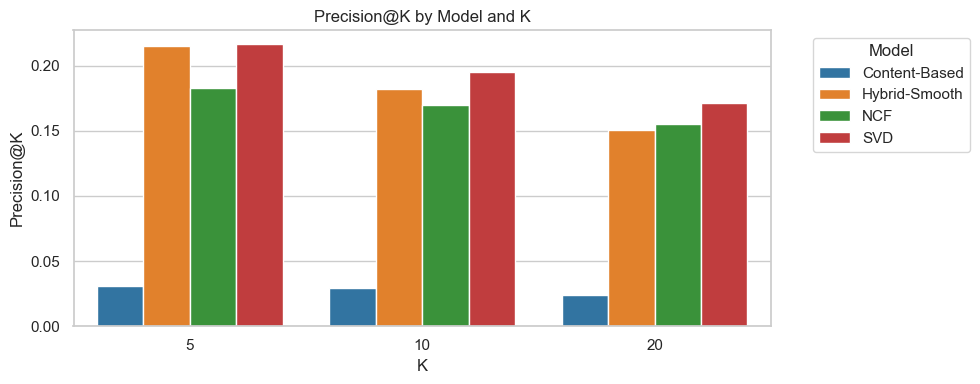

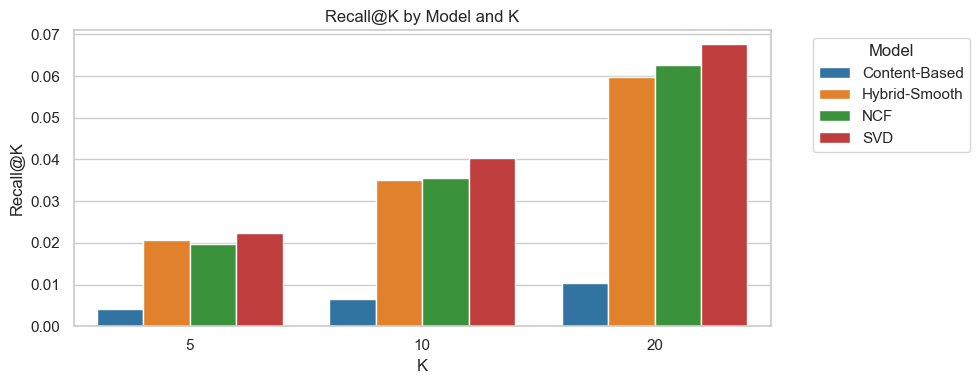

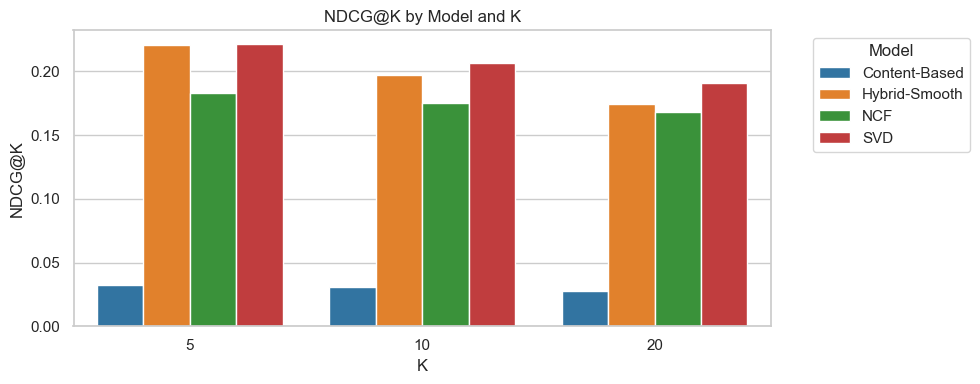

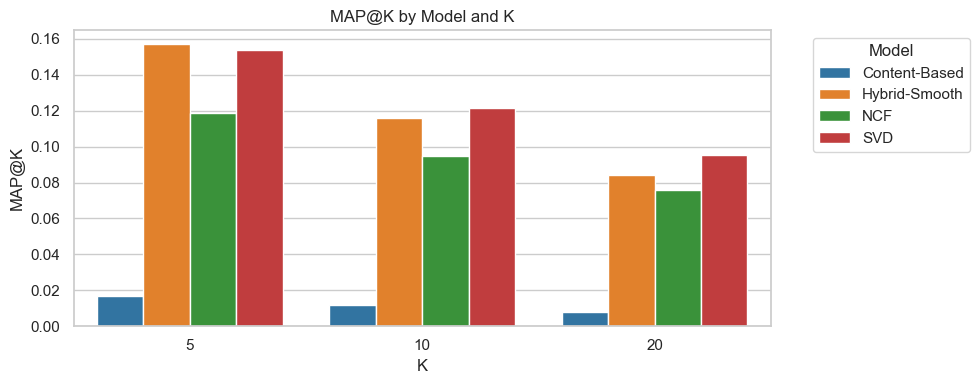

In [6]:
# Plot Precision, Recall, NDCG, MAP
for m in ['Precision@K','Recall@K','NDCG@K','MAP@K']:
    fig = plot_metric(m, height=4)
    fname = m.replace('@', 'at')
    fig.savefig(f'../figures/{fname}_by_model.png', dpi=200)
    display(fig)
    plt.close(fig)

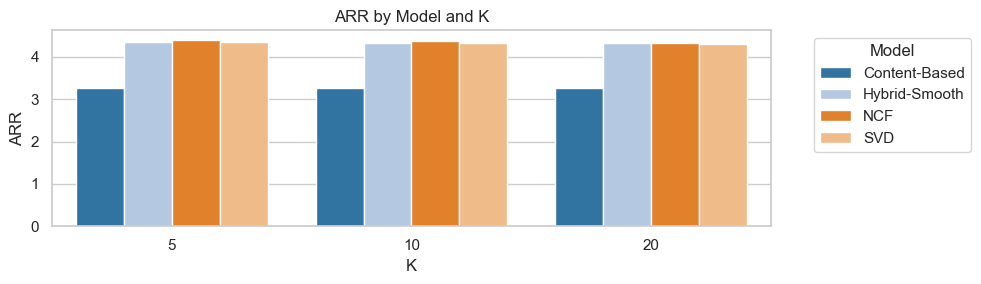

In [7]:
# Plot ARR (separate scale)
fig = plot_metric('ARR', height=3, palette='tab20')
fig.savefig('../figures/ARR_by_model.png', dpi=200)
display(fig)
plt.close(fig)

In [8]:
# Quick summary: best model per metric/K (by value)
summary = []
metrics = ['Precision@K','Recall@K','ARR','NDCG@K','MAP@K']
for k in sorted(plot_df['K'].unique()):
    dfk = plot_df[plot_df['K']==k]
    for metric in metrics:
        best = dfk.loc[dfk[metric].idxmax()]
        summary.append({'K':k, 'metric':metric, 'best_model':best['model'], 'value':best[metric]})
pd.DataFrame(summary).pivot(index='K', columns='metric', values=['best_model','value']).head()

best_model                                                value  \
metric        ARR          MAP@K NDCG@K Precision@K Recall@K       ARR   
K                                                                        
5             NCF  Hybrid-Smooth    SVD         SVD      SVD   4.40869   
10            NCF            SVD    SVD         SVD      SVD  4.373795   
20            NCF            SVD    SVD         SVD      SVD  4.330205   

                                                  
metric     MAP@K    NDCG@K Precision@K  Recall@K  
K                                                 
5       0.156926  0.221113    0.216226  0.022276  
10      0.121442  0.206526    0.195297   0.04041  
20      0.095332  0.191058    0.170988  0.067589